# Análises da FUVEST

Exploração dos dados de relação candidato vaga da [FUVEST](https://www.fuvest.br/acervo-vestibular)


In [15]:
import pandas as pd
from pathlib import Path

arquivo = Path("dados_cursos.csv")
dados = pd.read_csv(arquivo, sep=";")

print(f"Registros: {len(dados):,}")

Registros: 3,063


In [ ]:
print(f"Período: {dados['ano'].min()} a {dados['ano'].max()}")
print(f"Registros: {len(dados):,}")
print(f"Colunas: {list(dados.columns)}")
print()

dados.info()
print()

Período: 1994 a 2026
Registros: 3,063
Colunas: ['ano', 'curso', 'vagas', 'inscritos', 'pontos_minimo', 'pontos_maximo', 'candidatos_por_vaga', 'perc_acertos']

<class 'pandas.DataFrame'>
RangeIndex: 3063 entries, 0 to 3062
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ano                  3063 non-null   int64  
 1   curso                3063 non-null   str    
 2   vagas                3063 non-null   int64  
 3   inscritos            3063 non-null   int64  
 4   pontos_minimo        3063 non-null   int64  
 5   pontos_maximo        3063 non-null   int64  
 6   candidatos_por_vaga  3063 non-null   float64
 7   perc_acertos         3063 non-null   float64
dtypes: float64(2), int64(5), str(1)
memory usage: 191.6 KB



## Evolução por ano

Quantidade de cursos (um registro por curso/unidade), total de vagas e inscritos, e relação candidato/vaga agregada de cada ano.

In [10]:
from decimal import ROUND_HALF_UP, Decimal


def calcular_candidatos_por_vaga(inscritos: int, vagas: int) -> float:
    return float(
        (Decimal(int(inscritos)) / Decimal(int(vagas))).quantize(
            Decimal("0.01"), rounding=ROUND_HALF_UP
        )
    )


por_ano = (
    dados.groupby("ano", as_index=False)
    .agg(
        cursos=("curso", "count"),
        vagas=("vagas", "sum"),
        inscritos=("inscritos", "sum"),
    )
    .sort_values("ano")
)

por_ano["candidatos_por_vaga"] = por_ano.apply(
    lambda linha: calcular_candidatos_por_vaga(linha["inscritos"], linha["vagas"]),
    axis=1,
)

por_ano

,ano,cursos,vagas,inscritos,candidatos_por_vaga
0,1994,70,8391,124228,14.80
1,1995,72,8401,122324,14.56
2,1996,74,8251,105492,12.79
3,1997,75,8258,106905,12.95
4,1998,77,8318,112414,13.51
5,1999,76,8494,112836,13.28
6,2000,65,7543,123457,16.37
7,2001,68,7727,121247,15.69
8,2002,73,8041,122806,15.27
9,2003,80,8561,134793,15.75


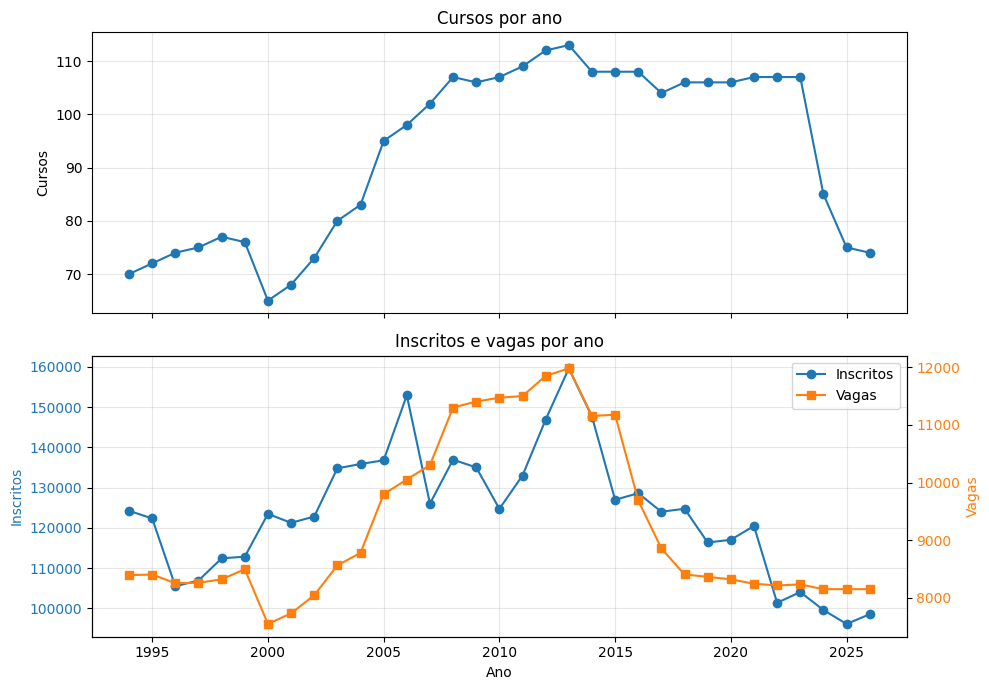

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(por_ano["ano"], por_ano["cursos"], marker="o")
axes[0].set_ylabel("Cursos")
axes[0].set_title("Cursos por ano")
axes[0].grid(True, alpha=0.3)

ax_inscritos = axes[1]
ax_vagas = ax_inscritos.twinx()

linha_inscritos = ax_inscritos.plot(
    por_ano["ano"], por_ano["inscritos"], marker="o", color="tab:blue", label="Inscritos"
)
linha_vagas = ax_vagas.plot(
    por_ano["ano"], por_ano["vagas"], marker="s", color="tab:orange", label="Vagas"
)

ax_inscritos.set_ylabel("Inscritos", color="tab:blue")
ax_vagas.set_ylabel("Vagas", color="tab:orange")
ax_inscritos.set_title("Inscritos e vagas por ano")
ax_inscritos.set_xlabel("Ano")
ax_inscritos.tick_params(axis="y", labelcolor="tab:blue")
ax_vagas.tick_params(axis="y", labelcolor="tab:orange")
ax_inscritos.grid(True, alpha=0.3)

ax_inscritos.legend(
    linha_inscritos + linha_vagas,
    [linha.get_label() for linha in linha_inscritos + linha_vagas],
    loc="upper right",
)

plt.tight_layout()
plt.show()

In [27]:
from IPython.display import display


def formatar_numero(valor) -> str:
    return f"{int(valor):,}".replace(",", ".")


def coluna_ano_valor(df: pd.DataFrame, coluna: str) -> pd.Series:
    return df.apply(
        lambda linha: f"{int(linha['ano'])} ({formatar_numero(linha[coluna])})",
        axis=1,
    )


def montar_tabela(coluna_esq: str, coluna_dir: str, menor: bool = False) -> pd.DataFrame:
    if menor:
        esq = por_ano.nsmallest(5, coluna_esq)[["ano", coluna_esq]].reset_index(drop=True)
        dir = por_ano.nsmallest(5, coluna_dir)[["ano", coluna_dir]].reset_index(drop=True)
    else:
        esq = por_ano.nlargest(5, coluna_esq)[["ano", coluna_esq]].reset_index(drop=True)
        dir = por_ano.nlargest(5, coluna_dir)[["ano", coluna_dir]].reset_index(drop=True)

    return pd.DataFrame(
        {
            f"Mais {coluna_esq}" if not menor else f"Menos {coluna_esq}": coluna_ano_valor(
                esq, coluna_esq
            ),
            f"Mais {coluna_dir}" if not menor else f"Menos {coluna_dir}": coluna_ano_valor(
                dir, coluna_dir
            ),
        }
    )


tabela_mais = montar_tabela("vagas", "inscritos")
tabela_menos = montar_tabela("vagas", "inscritos", menor=True)

display(tabela_mais)
display(tabela_menos)

,Mais vagas,Mais inscritos
0,2013 (11.982),2013 (159.609)
1,2012 (11.852),2006 (152.927)
2,2011 (11.502),2014 (147.634)
3,2010 (11.472),2012 (146.892)
4,2009 (11.407),2008 (136.937)


,Menos vagas,Menos inscritos
0,2000 (7.543),2025 (96.120)
1,2001 (7.727),2026 (98.523)
2,2002 (8.041),2024 (99.578)
3,2024 (8.147),2022 (101.371)
4,2025 (8.147),2023 (104.044)


In [28]:
def valor_ano(ano: int, coluna: str) -> int:
    return int(por_ano.loc[por_ano["ano"] == ano, coluna].iloc[0])


def formatar_variacao(valor: int) -> str:
    sinal = "+" if valor > 0 else ""
    return f"{sinal}{formatar_numero(valor)}"


def formatar_percentual(valor_inicial: int, variacao: int) -> str:
    pct = (variacao / valor_inicial) * 100
    return f"{pct:+.1f}%".replace(".", ",")


def linha_comparacao(ano_ini: int, ano_fim: int, coluna: str) -> dict:
    valor_ini = valor_ano(ano_ini, coluna)
    valor_fim = valor_ano(ano_fim, coluna)
    variacao = valor_fim - valor_ini

    linha = {
        "Comparação": f"{coluna.capitalize()} ({ano_ini} → {ano_fim})",
        "Valor inicial": formatar_numero(valor_ini),
        "Valor final": formatar_numero(valor_fim),
        "Variação": formatar_variacao(variacao),
    }

    linha["Variação (%)"] = formatar_percentual(valor_ini, variacao)

    return linha


comparacoes = [
    linha_comparacao(2000, 2013, "vagas"),
    linha_comparacao(2013, 2026, "vagas"),
    linha_comparacao(1996, 2013, "inscritos"),
    linha_comparacao(2013, 2026, "inscritos"),
]

tabela_comparacoes = pd.DataFrame(comparacoes)
display(tabela_comparacoes)

,Comparação,Valor inicial,Valor final,Variação,Variação (%)
0,Vagas (2000 → 2013),7.543,11.982,+4.439,"+58,8%"
1,Vagas (2013 → 2026),11.982,8.147,-3.835,"-32,0%"
2,Inscritos (1996 → 2013),105.492,159.609,+54.117,"+51,3%"
3,Inscritos (2013 → 2026),159.609,98.523,-61.086,"-38,3%"


## Percentual mínimo para passar

Percentual de acertos necessário na prova (`perc_acertos`), calculado a partir da nota de corte (`pontos_minimo`) e do total de questões do ano. Os 5 cursos com maior percentual exigido em cada ano.

In [ ]:
def formatar_percentual(valor: float) -> str:
    return f"{valor:.2f}%".replace(".", ",")


top5_por_ano = (
    dados.assign(perc_acertos=pd.to_numeric(dados["perc_acertos"], errors="coerce"))
    .dropna(subset=["perc_acertos"])
    .sort_values(["ano", "perc_acertos"], ascending=[True, False])
    .groupby("ano", group_keys=False)
    .head(5)
    .assign(pos=lambda df: df.groupby("ano").cumcount() + 1)
    .loc[:, ["ano", "pos", "curso", "perc_acertos", "pontos_minimo", "candidatos_por_vaga"]]
    .reset_index(drop=True)
)

for ano in sorted(top5_por_ano["ano"].unique()):
    tabela_ano = top5_por_ano[top5_por_ano["ano"] == ano].copy()
    tabela_ano["perc_acertos"] = tabela_ano["perc_acertos"].map(formatar_percentual)
    tabela_ano["pontos_minimo"] = tabela_ano["pontos_minimo"].map(
        lambda v: f"{v:g}".replace(".", ",")
    )
    tabela_ano["candidatos_por_vaga"] = tabela_ano["candidatos_por_vaga"].map(
        lambda v: f"{v:.2f}".replace(".", ",")
    )
    tabela_ano = tabela_ano.rename(
        columns={
            "pos": "#",
            "perc_acertos": "% acertos",
            "pontos_minimo": "Nota corte",
            "candidatos_por_vaga": "Cand./vaga",
        }
    )

    print(f"Ano {ano}")
    display(tabela_ano.drop(columns=["ano"]))
    print()

## Medicina: percentual de acertos para passar

Evolução do percentual mínimo de acertos (`perc_acertos`) exigido para aprovação em Medicina, ano a ano. O nome do curso varia entre os anos (`Medicina`, `Medicina e Ciências Médicas`, `MEDICINA`, `Medicina (São Paulo)` etc.) e exclui Medicina Veterinária. Nos anos com mais de uma unidade de Medicina (São Paulo, Ribeirão Preto, Bauru), considera-se o maior percentual.

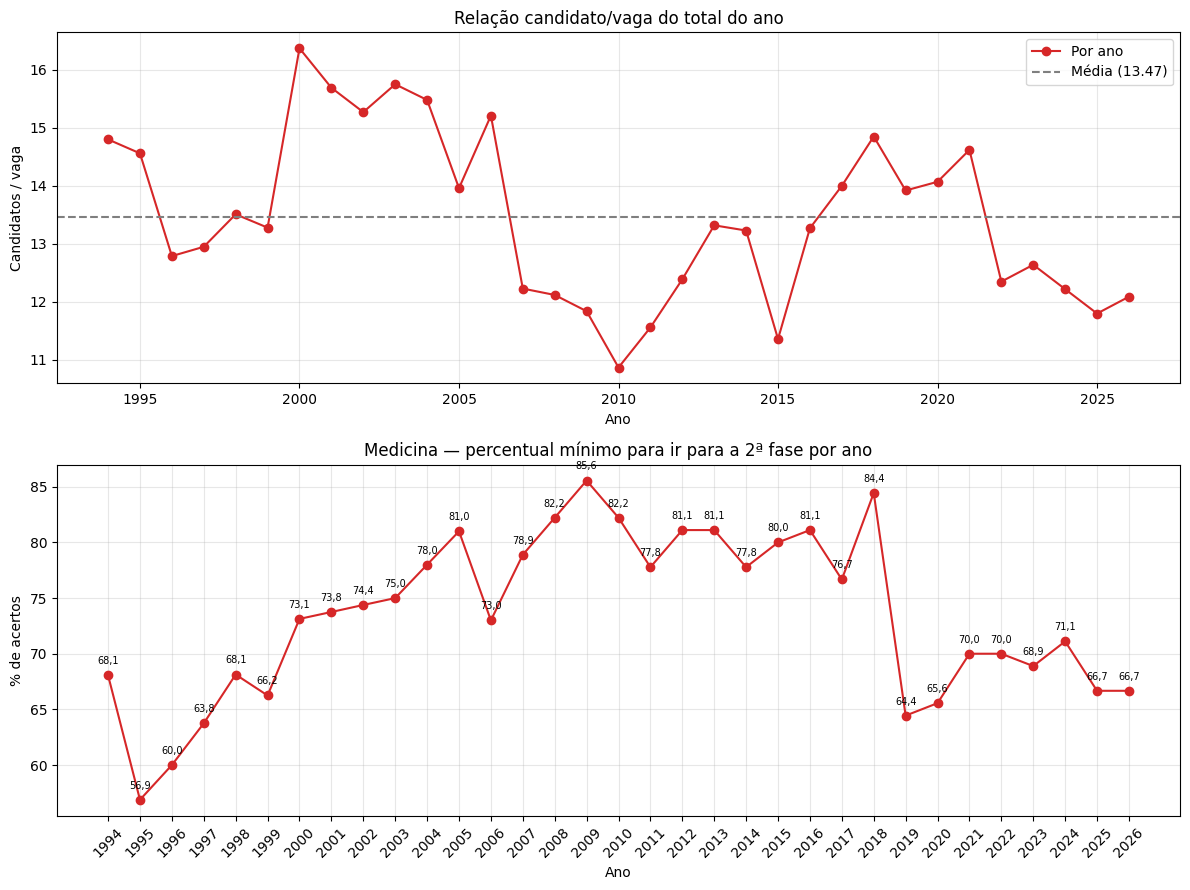

In [12]:
import matplotlib.pyplot as plt

eh_medicina = dados["curso"].str.contains("medicina", case=False, na=False)
eh_veterinaria = dados["curso"].str.contains("veterin", case=False, na=False)

medicina = dados[eh_medicina & ~eh_veterinaria].copy()
medicina["perc_acertos"] = pd.to_numeric(medicina["perc_acertos"], errors="coerce")

medicina_por_ano = (
    medicina.dropna(subset=["perc_acertos"])
    .groupby("ano", as_index=False)["perc_acertos"]
    .max()
    .sort_values("ano")
)

fig, axes = plt.subplots(2, 1, figsize=(12, 9))

media_candidatos_por_vaga = por_ano["candidatos_por_vaga"].mean()

axes[0].plot(
    por_ano["ano"],
    por_ano["candidatos_por_vaga"],
    marker="o",
    color="tab:red",
    label="Por ano",
)
axes[0].axhline(
    media_candidatos_por_vaga,
    color="tab:gray",
    linestyle="--",
    linewidth=1.5,
    label=f"Média ({media_candidatos_por_vaga:.2f})",
)
axes[0].set_ylabel("Candidatos / vaga")
axes[0].set_xlabel("Ano")
axes[0].set_title("Relação candidato/vaga do total do ano")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    medicina_por_ano["ano"],
    medicina_por_ano["perc_acertos"],
    marker="o",
    color="tab:red",
)

for _, linha in medicina_por_ano.iterrows():
    rotulo = f"{linha['perc_acertos']:.1f}".replace(".", ",")
    axes[1].annotate(
        rotulo,
        (linha["ano"], linha["perc_acertos"]),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=7,
    )

axes[1].set_xlabel("Ano")
axes[1].set_ylabel("% de acertos")
axes[1].set_title("Medicina — percentual mínimo para ir para a 2ª fase por ano")
axes[1].set_xticks(medicina_por_ano["ano"])
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()